In [1]:
from cuml.cluster import KMeans
import numpy as np
from sklearn.datasets import fetch_openml
#from keras.datasets import mnist
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torch
import pandas as pd
import cudf
import pickle
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
def init(image_dim, patch_size, preset_seed = np.zeros((3,3)), custom_seed=False):
    # Generate window
    window = np.zeros(image_dim, dtype=np.float32)
    # print('window', window.shape)

    # Generate window mask
    h, w = window.shape
    mask = np.zeros((h, w), dtype=np.float32)
    # print('mask', mask.shape)

    # Initialize window with this seed
    seed = np.random.random((3,3))
    if custom_seed:
        seed = preset_seed
    # seed = np.zeros((3,3))
    # print('seed', seed)

    # Place seed in center of window
    ph, pw = (h//2)-1, (w//2)-1
    window[ph:ph+3, pw:pw+3] = seed
    mask[ph:ph+3, pw:pw+3] = 1

    # Obtain padded versions of window and mask
    win = patch_size//2
    padded_window = cv2.copyMakeBorder(window, top=win, bottom=win, left=win, right=win, borderType=cv2.BORDER_CONSTANT, value=0.)
    padded_mask = cv2.copyMakeBorder(mask, top=win, bottom=win, left=win, right=win, borderType=cv2.BORDER_CONSTANT, value=0.)
    
    # Obtain views of the padded window and mask
    window = padded_window[win:-win, win:-win]
    mask = padded_mask[win:-win, win:-win]

    return window, mask, padded_window, padded_mask, win

def ssdnorm_cuda(sample_set, window, mask):
    wh, ww = window.shape

    #fig, axes = plt.subplots(1,4,figsize=(10,10))
    window_tensor = torch.tensor(window, dtype=torch.float32, device=device)
    mask_tensor = torch.tensor(mask, dtype=torch.float32, device=device)

    def create_gaussian_kernel(size=wh, sigma=1.0):
        k = torch.arange(size, dtype=torch.float32) - (size - 1) / 2
        gauss = torch.exp(-0.5 * (k / sigma)**2)
        kernel = gauss[:, None] * gauss[None, :]
        return kernel / kernel.sum()

    gaussian_kernel = create_gaussian_kernel().to(device) * mask_tensor
    #axes[0].imshow(gaussian_kernel, cmap='gray')

    #print('squared diff', sample_set.shape, window_tensor.shape, gaussian_kernel.shape)
    batchsize = 4000000
    finished = 0
    total_samples = sample_set.shape[0]
    total_ssd = gaussian_kernel.sum(dim=1).sum(dim=0)
    normalized_ssd = torch.empty(total_samples, dtype=torch.float32)
    while finished < total_samples:
        end = min(finished + batchsize, total_samples)
        diff = (sample_set[finished:end,:,:] - window_tensor)# * prob_matrix[finished:end,:,:]
        squared = diff**2
        ssdxg = squared * gaussian_kernel# * prob_matrix[finished:end,:,:]
        ssd = ssdxg.sum(dim=2).sum(dim=1)
        normalized_ssd[finished:end] = ssd[:] / total_ssd
        finished = end
    
    return normalized_ssd

def ssdnorm_conv(data, data_squared, window, mask, padding=0):
    wh, ww = window.shape
    total_images, dh, dw= data.shape

    ph = dh - wh + 1
    pw = dw - ww + 1
    data_reshape = data.reshape(-1, 1, dh, dw)
    data_square_reshape = data_squared.reshape(-1, 1, dh, dw)
    window_reshape = window.reshape(1, 1, wh, ww)
    mask_reshape = mask.reshape(1, 1, wh, ww)

    window_tensor = torch.tensor(window_reshape, dtype=torch.float32, device=device)
    mask_tensor = torch.tensor(mask_reshape, dtype=torch.float32, device=device)

    def create_gaussian_kernel(size=wh, sigma=1.0):
        k = torch.arange(size, dtype=torch.float32) - (size - 1) / 2
        gauss = torch.exp(-0.5 * (k / sigma)**2)
        kernel = gauss[:, None] * gauss[None, :]
        return kernel / kernel.sum()

    gaussian_kernel = create_gaussian_kernel().reshape(1, 1, wh, ww).to(device) * mask_tensor
    window_gaussian = (window_tensor*gaussian_kernel)

    window_square = torch.sum(window_tensor**2 * gaussian_kernel)
    twowx_term = torch.nn.functional.conv2d(input=data_reshape, weight=window_gaussian, padding=padding) * 2
    xsquared_term = torch.nn.functional.conv2d(input=data_square_reshape, weight=gaussian_kernel, padding=padding)

    total_ssd = gaussian_kernel.sum(dim=0).sum(dim=0).sum(dim=0).sum(dim=0)
    ssdxg = xsquared_term + window_square - twowx_term
    normalized_ssd = ssdxg / total_ssd
    ssdnorm_reshape = normalized_ssd.reshape(-1, 1)

    return ssdnorm_reshape

def choose_index(ssd_list, image_dim, windowsize, vis = False, error_rate = 0.2):
    min_val = torch.min(ssd_list)
    if min_val < 0 :
        #print('negative value', min)
        min_val = 0
    threshold = min_val * (1. + error_rate)
    valid_indices = torch.where(ssd_list <= threshold)[0]
    N = valid_indices.shape[0]
    selection = np.random.choice(np.arange(N), size=1)

    sample_index = valid_indices[selection].item() #torch.argmin(ssds_conv).item()

    patch_h = image_dim - windowsize + 1
    shift = windowsize // 2
    patches_p_image = patch_h * patch_h
    image_index = sample_index // patches_p_image
    into = sample_index % patches_p_image
    into_index = ((into // patch_h) + shift, (into % patch_h) + shift)
    if vis == True:
        print('min:', min.cpu().numpy(), 'thres:', threshold.cpu().numpy(), 'indices', valid_indices.cpu().numpy(), 'select', sample_index)
    
    return sample_index, image_index, into_index


In [3]:
def gen_image_conv(data, data_squared, gen_dim, windowsize, padding = 0, visualize = False):
    _, dh, dw = data.shape
    window, mask, pad_window, pad_mask, pad = init(gen_dim, windowsize)
    while np.sum(mask) < gen_dim[0] * gen_dim[1]:
        dilated_image = cv2.dilate(mask, np.ones((3,3)), iterations=1)
        new_mask = dilated_image - mask
        new_indices = np.where(new_mask == 1)
        cnt = 0
        if visualize:
            figures = 6
            fig, axes = plt.subplots(new_indices[0].shape[0], figures, figsize=(figures * 3, new_indices[0].shape[0] * 3))
        for x, y in zip(new_indices[0], new_indices[1]):
            sub_pic = pad_window[x-(windowsize//2)+pad : x+(windowsize//2+1)+pad, y-(windowsize//2)+pad : y+(windowsize//2+1)+pad]
            sub_mask = pad_mask[x-(windowsize//2)+pad : x+(windowsize//2+1)+pad, y-(windowsize//2)+pad : y+(windowsize//2+1)+pad]

            ssds_conv = ssdnorm_conv(data, data_squared, sub_pic, sub_mask, padding=padding)
            sample_index, image_index, into_index = choose_index(ssds_conv, dh, windowsize, padding)
            #ssds_cuda = ssdnorm_cuda(patches, sub_pic, sub_mask)
            #sample_index_cuda, image_index_cuda,into_index_cuda = choose_index(ssds_cuda, 28, windowsize, vis=False)

            window[x,y] = data[image_index][into_index[0], into_index[1]].item()
            mask[x,y] = 1
            #shift_amount = pad
            #pad_window[x+shift_amount,y+shift_amount] = images[image_index][into_index[0], into_index[1]].item()
            #pad_mask[x+shift_amount,y+shift_amount] = 1

            if visualize:
                axes[cnt][0].imshow(pad_window, cmap='gray')
                axes[cnt][0].set_title(f'padded {x + pad}, {y + pad}')
                axes[cnt][0].scatter([y + pad], [x + pad], color='red', s=100, marker='x')
                axes[cnt][0].axis('off')
    
                axes[cnt][1].imshow(window, cmap='gray')
                axes[cnt][1].set_title(f'window {y} {x}')
                axes[cnt][1].axis('off')
    
                axes[cnt][2].imshow(data[image_index].reshape(28,28).cpu(), cmap='gray', vmin=0, vmax=1)
                axes[cnt][2].set_title(f'{image_index}')
                axes[cnt][2].scatter([into_index[1]], [into_index[0]], color='red', s=100, marker='x')
                axes[cnt][2].axis('off')
    
                axes[cnt][3].imshow(data[image_index].reshape(28,28)[into_index[0] - 2:into_index[0] + 3, into_index[1] - 2: into_index[1] + 3].cpu(), cmap='gray', vmin=0, vmax=1)
                axes[cnt][3].set_title(f'{into_index[0]} {into_index[1]}')
                axes[cnt][3].scatter([2], [2], color='red', s=100, marker='x')
                axes[cnt][3].axis('off')
    
                axes[cnt][4].imshow(pad_mask, cmap='gray', vmin=0, vmax=1)
                axes[cnt][4].set_title(f'padded_mask')
                axes[cnt][4].axis('off')
    
                axes[cnt][5].imshow(mask, cmap='gray', vmin=0, vmax=1)
                axes[cnt][5].set_title(f'mask')
                axes[cnt][5].axis('off')
    
                # axes[cnt][4].imshow(images[image_index_cuda].reshape(28,28).cpu(), cmap='gray', vmin=0, vmax=1)
                # axes[cnt][4].set_title(f'{image_index_cuda}')
                # axes[cnt][4].scatter([into_index_cuda[0]], [into_index_cuda[1]], color='red', s=100, marker='x')
                # axes[cnt][4].axis('off')
    
                # axes[cnt][5].imshow(patches[sample_index_cuda].reshape(5,5).cpu(), cmap='gray', vmin=0, vmax=1)
                # axes[cnt][5].set_title(f'{into_index_cuda[0]} {into_index_cuda[1]}')
                # axes[cnt][5].scatter([2], [2], color='red', s=100, marker='x')
                # axes[cnt][5].axis('off')
                cnt +=1
    return window

def gen_image_conv_locality(data, data_squared, gen_dim, windowsize, locality, seed=None, padding = 0, visualize = False):
    dlen, dh, dw = data.shape

    random_seed = data[np.random.randint(0, dlen), (dh//2)-1:(dh//2)+2, (dw//2)-1:(dw//2)+2].cpu().numpy()
    noise = np.random.uniform(-0.1, 0.1, (3, 3))
    pre_seed = random_seed + noise
    pre_seed = np.clip(pre_seed, 0, 1)

    window, mask, pad_window, pad_mask, pad = init(gen_dim, windowsize, preset_seed = pre_seed, custom_seed=True) #preset_seed = pre_seed
    while np.sum(mask) < gen_dim[0] * gen_dim[1]:
        dilated_image = cv2.dilate(mask, np.ones((3,3)), iterations=1)
        new_mask = dilated_image - mask
        new_indices = np.where(new_mask == 1)
        cnt = 0
        if visualize:
            figures = 6
            fig, axes = plt.subplots(new_indices[0].shape[0], figures, figsize=(figures * 3, new_indices[0].shape[0] * 3))
        for x, y in zip(new_indices[0], new_indices[1]):
            sub_pic = pad_window[x-(windowsize//2)+pad : x+(windowsize//2+1)+pad, y-(windowsize//2)+pad : y+(windowsize//2+1)+pad]
            sub_mask = pad_mask[x-(windowsize//2)+pad : x+(windowsize//2+1)+pad, y-(windowsize//2)+pad : y+(windowsize//2+1)+pad]

            bounded_x = min(dh-locality - 1, max(locality, x))
            bounded_y = min(dw-locality - 1, max(locality, y))
            sub_data = data[:, bounded_x-locality:bounded_x+locality+1, bounded_y-locality:bounded_y+locality+1]
            sub_data_square = data_squared[:, bounded_x-locality:bounded_x+locality+1, bounded_y-locality:bounded_y+locality+1]

            ssds_conv = ssdnorm_conv(sub_data, sub_data_square, sub_pic, sub_mask, padding=padding)
            sample_index, image_index, into_index = choose_index(ssds_conv, locality*2+1, windowsize, padding)
            #ssds_cuda = ssdnorm_cuda(patches, sub_pic, sub_mask)
            #sample_index_cuda, image_index_cuda,into_index_cuda = choose_index(ssds_cuda, 28, windowsize, vis=False)

            window[x,y] = sub_data[image_index][into_index[0], into_index[1]].item()
            mask[x,y] = 1
            #shift_amount = pad
            #pad_window[x+shift_amount,y+shift_amount] = images[image_index][into_index[0], into_index[1]].item()
            #pad_mask[x+shift_amount,y+shift_amount] = 1

            if visualize:
                axes[cnt][0].imshow(pad_window, cmap='gray')
                axes[cnt][0].set_title(f'padded {x + pad}, {y + pad}')
                axes[cnt][0].scatter([y + pad], [x + pad], color='red', s=100, marker='x')
                axes[cnt][0].axis('off')
    
                axes[cnt][1].imshow(window, cmap='gray')
                axes[cnt][1].set_title(f'window {y} {x}')
                axes[cnt][1].axis('off')
    
                axes[cnt][2].imshow(data[image_index].reshape(28,28).cpu(), cmap='gray', vmin=0, vmax=1)
                axes[cnt][2].set_title(f'{image_index}')
                axes[cnt][2].scatter([into_index[1]], [into_index[0]], color='red', s=100, marker='x')
                axes[cnt][2].axis('off')
    
                axes[cnt][3].imshow(data[image_index].reshape(28,28)[into_index[0] - 2:into_index[0] + 3, into_index[1] - 2: into_index[1] + 3].cpu(), cmap='gray', vmin=0, vmax=1)
                axes[cnt][3].set_title(f'{into_index[0]} {into_index[1]}')
                axes[cnt][3].scatter([2], [2], color='red', s=100, marker='x')
                axes[cnt][3].axis('off')
    
                axes[cnt][4].imshow(pad_mask, cmap='gray', vmin=0, vmax=1)
                axes[cnt][4].set_title(f'padded_mask')
                axes[cnt][4].axis('off')
    
                axes[cnt][5].imshow(mask, cmap='gray', vmin=0, vmax=1)
                axes[cnt][5].set_title(f'mask')
                axes[cnt][5].axis('off')
    
                # axes[cnt][4].imshow(images[image_index_cuda].reshape(28,28).cpu(), cmap='gray', vmin=0, vmax=1)
                # axes[cnt][4].set_title(f'{image_index_cuda}')
                # axes[cnt][4].scatter([into_index_cuda[0]], [into_index_cuda[1]], color='red', s=100, marker='x')
                # axes[cnt][4].axis('off')
    
                # axes[cnt][5].imshow(patches[sample_index_cuda].reshape(5,5).cpu(), cmap='gray', vmin=0, vmax=1)
                # axes[cnt][5].set_title(f'{into_index_cuda[0]} {into_index_cuda[1]}')
                # axes[cnt][5].scatter([2], [2], color='red', s=100, marker='x')
                # axes[cnt][5].axis('off')
                cnt +=1
    return window

def gen_image_cuda(data, gen_dim, windowsize, padding = 0, visualize = False):
    _, dh, dw = data.shape
    window, mask, pad_window, pad_mask, pad = init(gen_dim, windowsize)
    while np.sum(mask) < gen_dim[0] * gen_dim[1]:
        dilated_image = cv2.dilate(mask, np.ones((3,3)), iterations=1)
        new_mask = dilated_image - mask
        new_indices = np.where(new_mask == 1)
        cnt = 0
        if visualize:
            figures = 6
            fig, axes = plt.subplots(new_indices[0].shape[0], figures, figsize=(figures * 3, new_indices[0].shape[0] * 3))
        for x, y in zip(new_indices[0], new_indices[1]):
            sub_pic = pad_window[x-(windowsize//2)+pad : x+(windowsize//2+1)+pad, y-(windowsize//2)+pad : y+(windowsize//2+1)+pad]
            sub_mask = pad_mask[x-(windowsize//2)+pad : x+(windowsize//2+1)+pad, y-(windowsize//2)+pad : y+(windowsize//2+1)+pad]

            ssds_conv = ssdnorm_cuda(data, sub_pic, sub_mask, padding=padding)
            sample_index, image_index, into_index = choose_index(ssds_conv, dh, windowsize, padding)
            #ssds_cuda = ssdnorm_cuda(patches, sub_pic, sub_mask)
            #sample_index_cuda, image_index_cuda,into_index_cuda = choose_index(ssds_cuda, 28, windowsize, vis=False)

            window[x,y] = data[image_index, dh//2, dw//2].item()
            mask[x,y] = 1
            #shift_amount = pad
            #pad_window[x+shift_amount,y+shift_amount] = images[image_index][into_index[0], into_index[1]].item()
            #pad_mask[x+shift_amount,y+shift_amount] = 1

            if visualize:
                axes[cnt][0].imshow(pad_window, cmap='gray')
                axes[cnt][0].set_title(f'padded {x + pad}, {y + pad}')
                axes[cnt][0].scatter([y + pad], [x + pad], color='red', s=100, marker='x')
                axes[cnt][0].axis('off')
    
                axes[cnt][1].imshow(window, cmap='gray')
                axes[cnt][1].set_title(f'window {y} {x}')
                axes[cnt][1].axis('off')
    
                axes[cnt][2].imshow(data[image_index].reshape(28,28).cpu(), cmap='gray', vmin=0, vmax=1)
                axes[cnt][2].set_title(f'{image_index}')
                axes[cnt][2].scatter([into_index[1]], [into_index[0]], color='red', s=100, marker='x')
                axes[cnt][2].axis('off')
    
                axes[cnt][3].imshow(data[image_index].reshape(28,28)[into_index[0] - 2:into_index[0] + 3, into_index[1] - 2: into_index[1] + 3].cpu(), cmap='gray', vmin=0, vmax=1)
                axes[cnt][3].set_title(f'{into_index[0]} {into_index[1]}')
                axes[cnt][3].scatter([2], [2], color='red', s=100, marker='x')
                axes[cnt][3].axis('off')
    
                axes[cnt][4].imshow(pad_mask, cmap='gray', vmin=0, vmax=1)
                axes[cnt][4].set_title(f'padded_mask')
                axes[cnt][4].axis('off')
    
                axes[cnt][5].imshow(mask, cmap='gray', vmin=0, vmax=1)
                axes[cnt][5].set_title(f'mask')
                axes[cnt][5].axis('off')
    
                # axes[cnt][4].imshow(images[image_index_cuda].reshape(28,28).cpu(), cmap='gray', vmin=0, vmax=1)
                # axes[cnt][4].set_title(f'{image_index_cuda}')
                # axes[cnt][4].scatter([into_index_cuda[0]], [into_index_cuda[1]], color='red', s=100, marker='x')
                # axes[cnt][4].axis('off')
    
                # axes[cnt][5].imshow(patches[sample_index_cuda].reshape(5,5).cpu(), cmap='gray', vmin=0, vmax=1)
                # axes[cnt][5].set_title(f'{into_index_cuda[0]} {into_index_cuda[1]}')
                # axes[cnt][5].scatter([2], [2], color='red', s=100, marker='x')
                # axes[cnt][5].axis('off')
                cnt +=1
    return window

images shape torch.Size([60000, 40, 40])
images max value tensor(1., device='cuda:0') tensor(1., device='cuda:0')


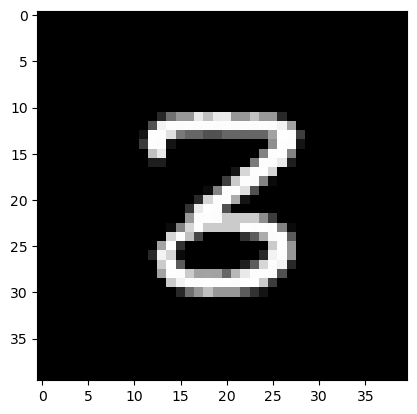

In [12]:
transform = transforms.Compose([
        transforms.ToTensor(),
        ])
train_dataset = datasets.MNIST(root='mnist_data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=60000, shuffle=True)
im_data_raw, _ = next(iter(train_loader))
padded_images = torch.nn.functional.pad(im_data_raw, (6, 6, 6, 6))
images = padded_images.reshape(-1, 40, 40).to(device)
images_square = torch.square(images)
print('images shape', images.shape)
print('images max value', torch.max(images), torch.max(images_square))

plt.imshow(images[0].cpu(), cmap='gray')

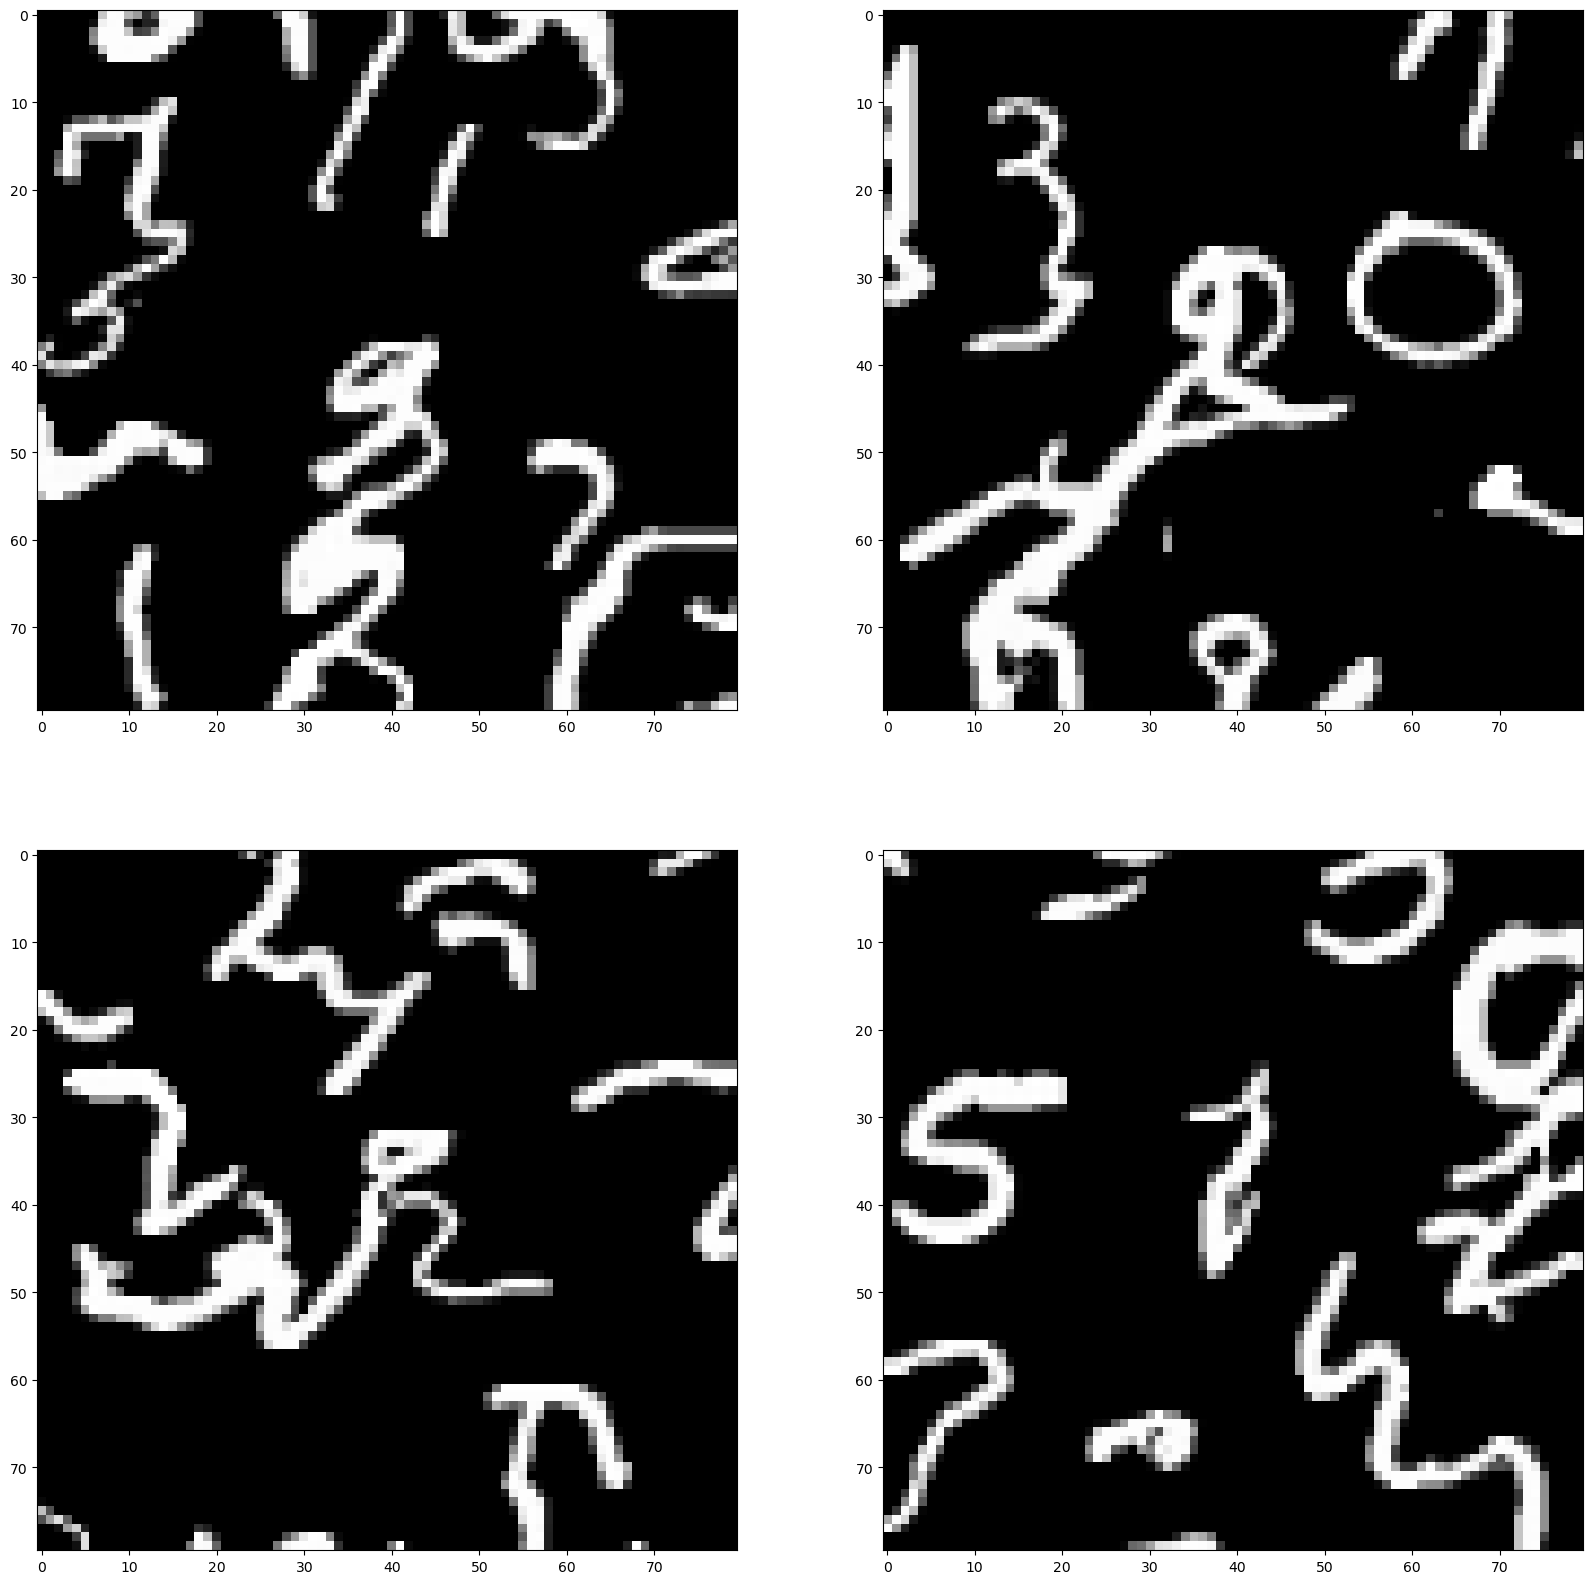

In [13]:
# HYPERPARAMETERS 
gen_dim = (80,80)
windowsize = 13
box = 2
fig, axes = plt.subplots(box,box, figsize=(20,20))
for row in range (0, box):
    for col in range (0, box):
        pic_out = gen_image_conv(images, images_square, gen_dim, windowsize, padding=0)
        axes[col][row].imshow(pic_out, cmap='gray', vmin=0, vmax=1)

images shape torch.Size([60000, 40, 40])
images max value tensor(1., device='cuda:0')


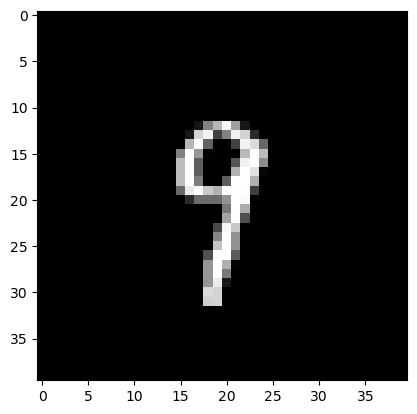

In [4]:
# DATA
transform = transforms.Compose([
        transforms.ToTensor(),
        ])
train_dataset = datasets.MNIST(root='mnist_data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=60000, shuffle=True)
im_data_raw, _ = next(iter(train_loader))
padded_images = torch.nn.functional.pad(im_data_raw, (6, 6, 6, 6))
images = padded_images.reshape(-1, 40, 40).to(device)
images_square = torch.square(images)
print('images shape', images.shape)
print('images max value', torch.max(images))

plt.imshow(images[0].cpu(), cmap='gray')

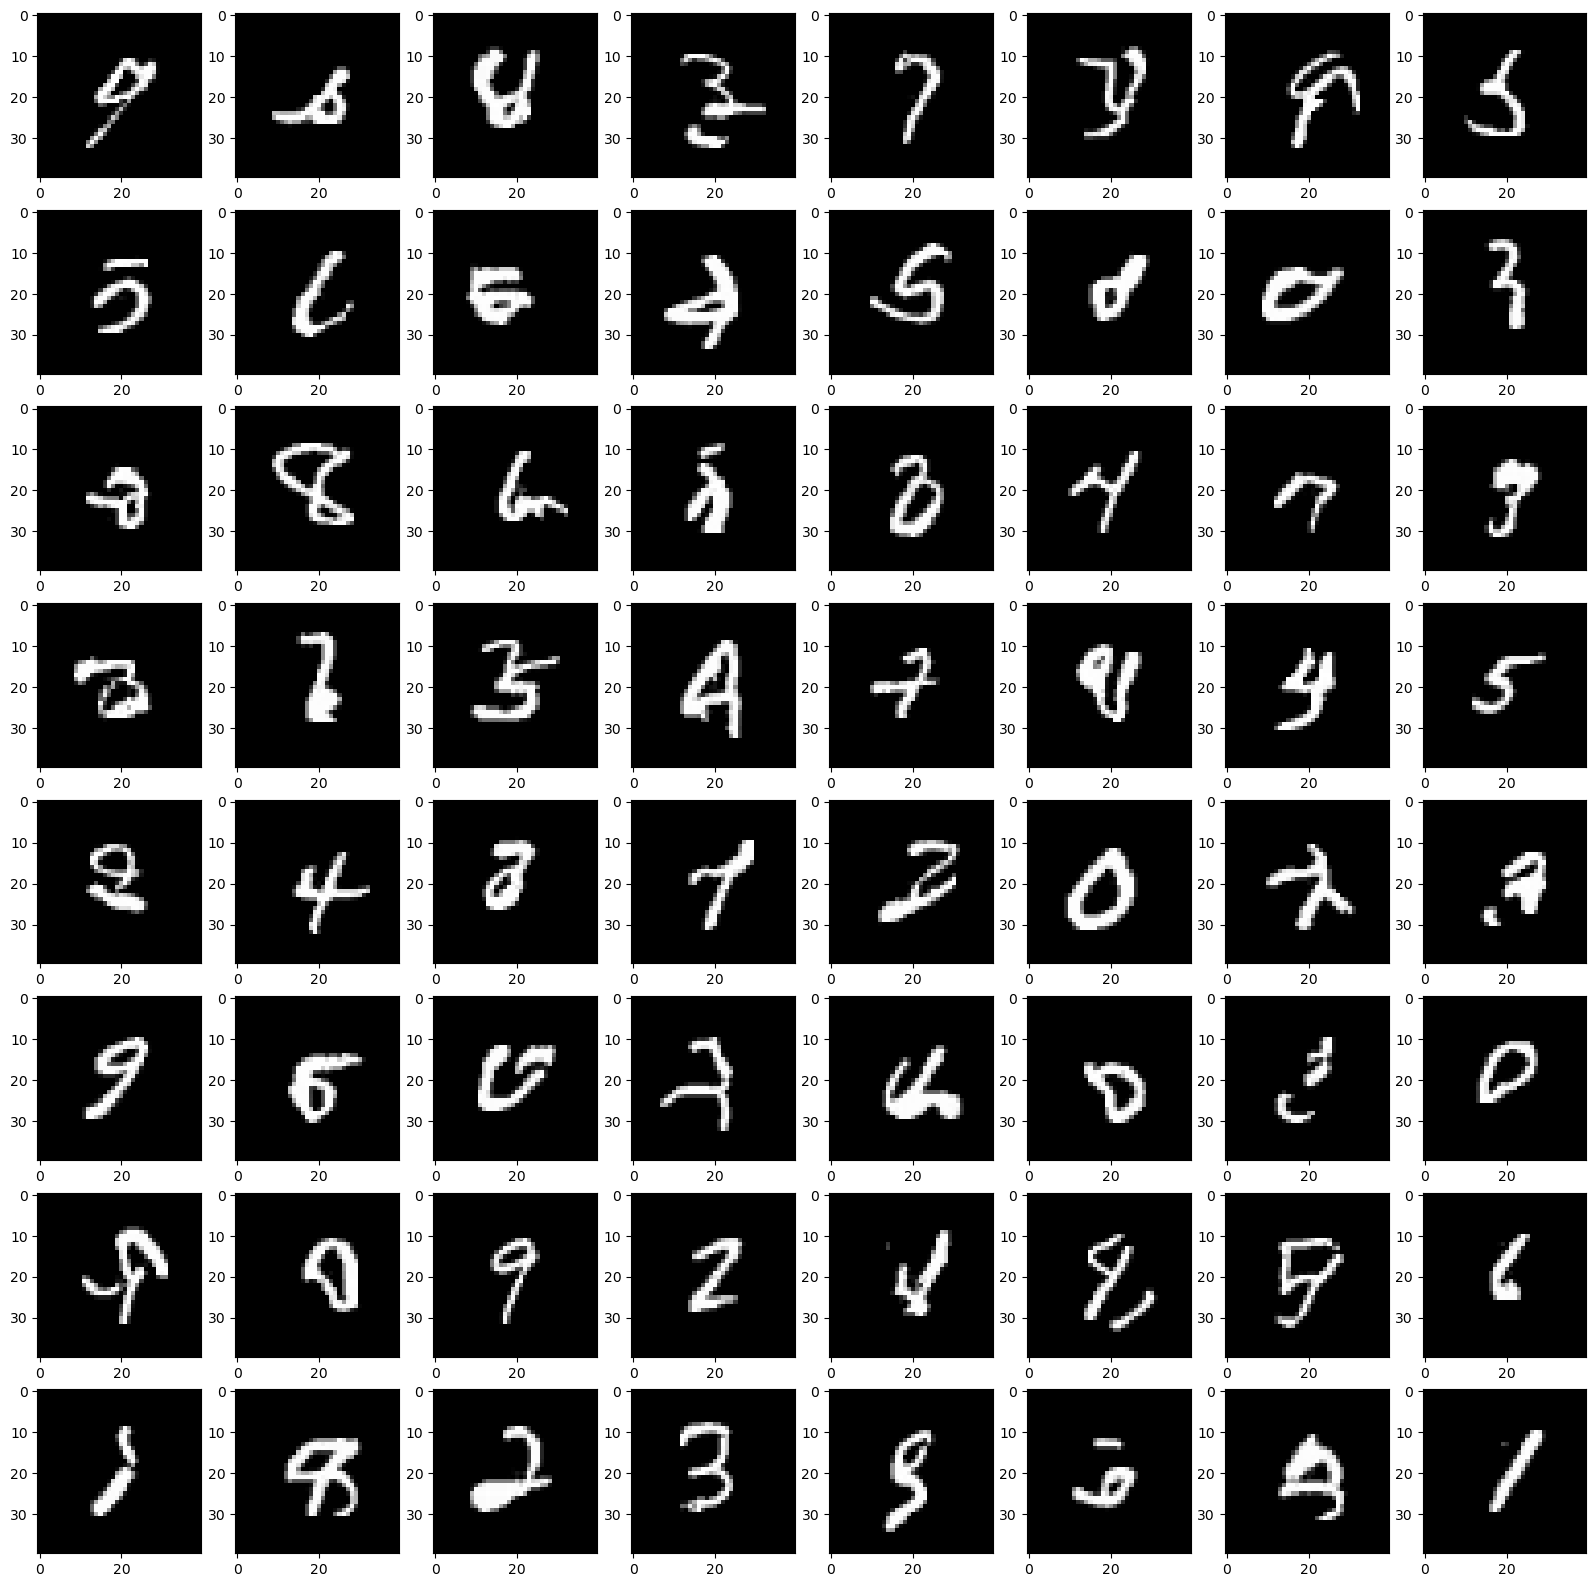

In [8]:
gen_dim = (40,40)
windowsize = 11
locality = 7 # how many pixels from the center should we be searching? 5 means 11x11 search window
box = 8
fig, axes = plt.subplots(box,box, figsize=(20,20))
for row in range (0, box):
    for col in range (0, box):
        pic_out = gen_image_conv_locality(images, images_square, gen_dim, windowsize, locality, seed='custom')
        axes[col][row].imshow(pic_out, cmap='gray', vmin=0, vmax=1)